# Zespolona transformata Fouriera

Na początek przećwiczmy, czym jest zespolona transformata Fouriera, jak jest liczona i jak ma się do transformaty rzeczywistej.

## Ćwiczenie 1 — DFT jako interpolacja

To ćwiczenie ma na celu pokazanie, że **transformata DFT jest rodzajem interpolacji** (dokładnie tej samej, którą poznaliśmy wcześniej — tylko w bazie zespolonych funkcji $e^{ix}$ zamiast sin/cos). Zobaczymy też podstawowe właściwości transformaty DFT: jak wyglądają jej współczynniki dla prostego sygnału i co dokładnie oznaczają.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sygnał testowy
N = 301
tmax = 2.0  # całkowita wielokrotność okresu sygnału (5 Hz -> 10 okresów w oknie obserwacji)
h = tmax / (N - 1)
t = np.linspace(0, tmax, N)
fs = 1/h

f_signal = lambda t: np.sin(2*np.pi*5*t)
y = f_signal(t)

print(f'N = {N}, h = {h:.6f} s, fs = {fs:.2f} Hz')

N = 301, h = 0.006667 s, fs = 150.00 Hz


Wektor próbek `y` musi być rozłożony równomiernie w czasie — dokładnie tak, jak w każdej interpolacji trygonometrycznej. Zobaczmy nasz sygnał testowy (sinusoidę 5 Hz) razem z próbkami, które faktycznie podamy do DFT:

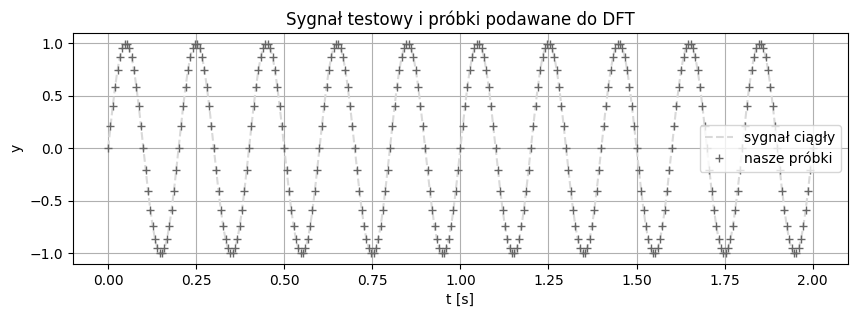

In [2]:
t_fine = np.linspace(0, tmax, 1001)
plt.figure(figsize=(10, 3))
plt.plot(t_fine, f_signal(t_fine), '--', color=[0.85, 0.85, 0.85], label='sygnał ciągły')
plt.plot(t, y, '+', color=[0.4, 0.4, 0.4], label='nasze próbki')
plt.xlabel('t [s]'); plt.ylabel('y')
plt.legend(); plt.grid(True)
plt.title('Sygnał testowy i próbki podawane do DFT')
plt.show()

In [3]:
dft = np.fft.fft(y)
ampl = np.abs(dft)
phase = np.angle(dft)

### Widmo zespolone — czego się spodziewać

Sama transformata DFT działa na próbkach (indeksowana względem $n$, nie względem czasu $t$) — położenie próbek w czasie jest dla samego algorytmu FFT nieistotne, liczy się tylko ich kolejność. Policzmy DFT naszego sygnału i wykreślmy współczynniki na płaszczyźnie zespolonej.

Wykres może wyglądać dziwnie na pierwszy rzut oka — ale zwróć uwagę, że wszystkie współczynniki są prawie równe zeru **poza dwoma symetrycznie rozłożonymi punktami względem zera**.

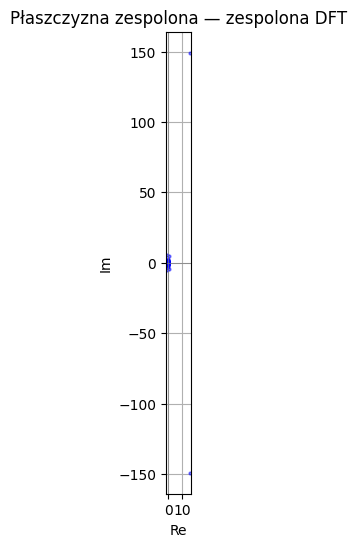

In [4]:
plt.figure(figsize=(6, 6))
plt.plot(dft.real, dft.imag, 'bo', markersize=2, alpha=0.5)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.gca().set_aspect('equal')
plt.xlabel('Re')
plt.ylabel('Im')
plt.title('Płaszczyzna zespolona — zespolona DFT')
plt.grid(True)
plt.show()

### Dlaczego akurat dwa symetryczne punkty? — wzory Eulera

Baza interpolacyjna zespolonej DFT to funkcje $e^{ix}$, a nie $\sin(x)$/$\cos(x)$ wprost. Ze wzorów Eulera:

$$\cos(x) = \frac{e^{ix} + e^{-ix}}{2}, \qquad \sin(x) = \frac{e^{ix} - e^{-ix}}{2i}$$

widać, że każda rzeczywista funkcja sin/cos rozkłada się na **parę** zespolonych wykładniczych $e^{+ix}$ i $e^{-ix}$ o przeciwnych znakach częstotliwości. Nasz sygnał to czysty $\sin(2\pi\cdot 5\cdot t)$ — zgodnie ze wzorem wyżej DFT musi więc dać dokładnie dwa niezerowe współczynniki: jeden przy $e^{+ix}$ (częstotliwość dodatnia) i jeden przy $e^{-ix}$ (częstotliwość **ujemna**), sprzężone ze sobą ($X[N-k] = \overline{X[k]}$). To właśnie w przetwarzaniu sygnałów nazywa się „częstotliwościami ujemnymi” w DFT.

Indeksy dwóch symetrycznych składowych: [ 10 291]
Amplitudy: [149.97329508 149.97329508]
Suma indeksów = 301 (powinna wynosić N = 301 -- symetria względem N/2)
Sprzężenie zespolone: X[10] = 15.6246-149.1572j
                      X[291] = 15.6246+149.1572j
                      sprzężenie X[10]* = 15.6246+149.1572j


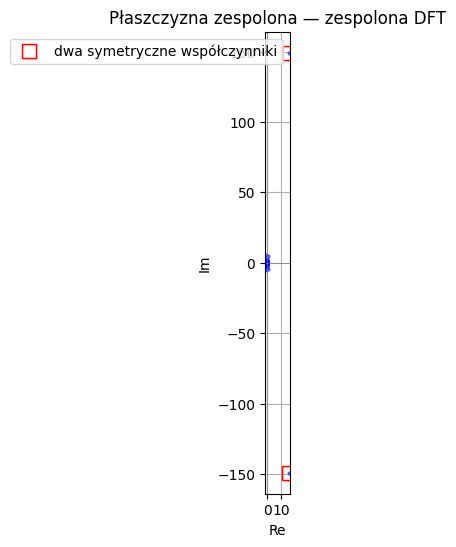

In [5]:
# Znajdź OBA symetryczne szczyty (nie tylko jeden dominujący indeks!)
outstanding_ind = np.where(ampl > 10)[0]
print(f'Indeksy dwóch symetrycznych składowych: {outstanding_ind}')
print(f'Amplitudy: {ampl[outstanding_ind]}')
print(f'Suma indeksów = {outstanding_ind.sum()} (powinna wynosić N = {N} -- symetria względem N/2)')
print(f'Sprzężenie zespolone: X[{outstanding_ind[0]}] = {dft[outstanding_ind[0]]:.4f}')
print(f'                      X[{outstanding_ind[1]}] = {dft[outstanding_ind[1]]:.4f}')
print(f'                      sprzężenie X[{outstanding_ind[0]}]* = {np.conj(dft[outstanding_ind[0]]):.4f}')

# Zaznacz oba punkty na wykresie płaszczyzny zespolonej
plt.figure(figsize=(6, 6))
plt.plot(dft.real, dft.imag, 'bo', markersize=2, alpha=0.5)
plt.plot(dft.real[outstanding_ind], dft.imag[outstanding_ind], 'rs', markersize=10,
         markerfacecolor='none', label='dwa symetryczne współczynniki')
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.gca().set_aspect('equal')
plt.xlabel('Re'); plt.ylabel('Im')
plt.title('Płaszczyzna zespolona — zespolona DFT')
plt.legend()
plt.grid(True)
plt.show()

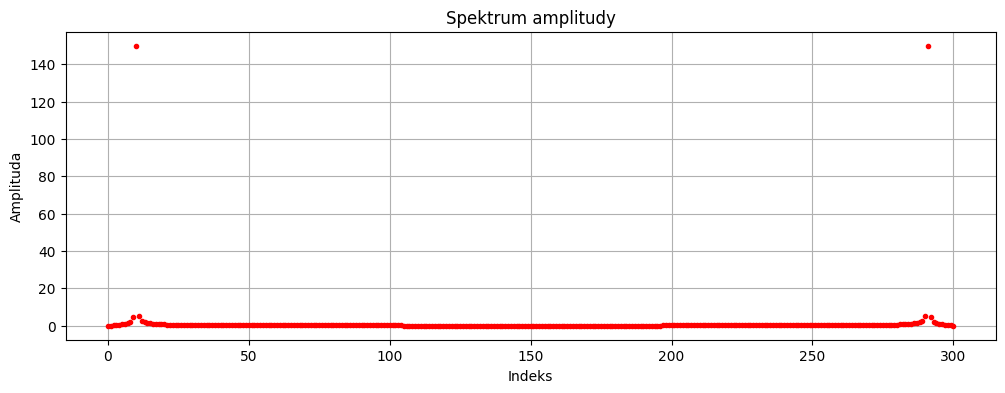

In [6]:
# Pełne spektrum amplitudy
plt.figure(figsize=(12, 4))
plt.plot(ampl, 'or', markersize=3)
plt.xlabel('Indeks')
plt.ylabel('Amplituda')
plt.title('Spektrum amplitudy')
plt.grid(True)
plt.show()

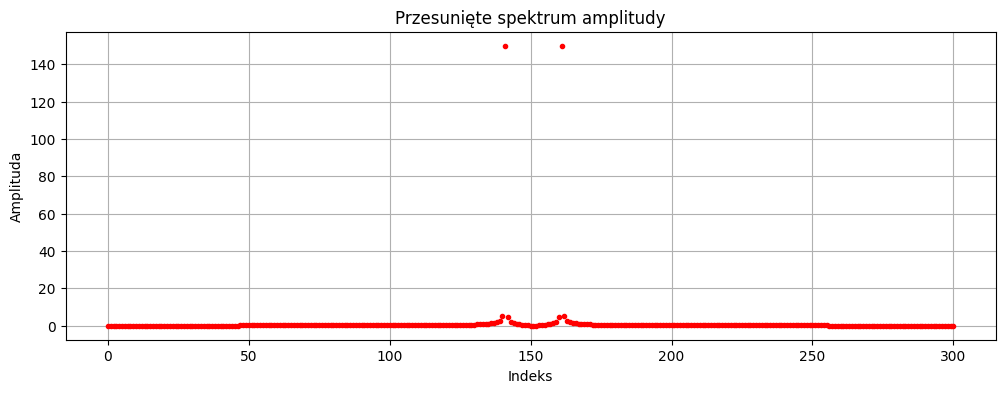

In [7]:
ampl_shifted = np.concatenate([ampl[N//2:], ampl[:N//2]])
phase_shifted = np.concatenate([phase[N//2:], phase[:N//2]])

plt.figure(figsize=(12, 4))
plt.plot(ampl_shifted, 'or', markersize=3)
plt.title('Przesunięte spektrum amplitudy')
plt.grid(True)
plt.xlabel('Indeks')
plt.ylabel('Amplituda')
plt.show()

In [8]:
frequency = np.linspace(0, fs, N, endpoint=False)
freq_centered = np.fft.fftfreq(N, d=1/fs)  # auto-centered

print(f'Osie częstotliwości (pierwsze 10):')
print(f'  Niewyśrodkowane: {frequency[:10]}')
print(f'  Wyśrodkowane:   {freq_centered[:10]}')

Osie częstotliwości (pierwsze 10):
  Niewyśrodkowane: [0.         0.49833887 0.99667774 1.49501661 1.99335548 2.49169435
 2.99003322 3.48837209 3.98671096 4.48504983]
  Wyśrodkowane:   [0.         0.49833887 0.99667774 1.49501661 1.99335548 2.49169435
 2.99003322 3.48837209 3.98671096 4.48504983]


In [9]:
# Pierwsze 10 współczynników
print('Pierwsze 10 współczynników:')
for i in range(10):
    print(f'  f[{i}] = {frequency[i]:.2f} Hz, ampl = {ampl[i]:.2e}')

Pierwsze 10 współczynników:
  f[0] = 0.00 Hz, ampl = 4.80e-15
  f[1] = 0.50 Hz, ampl = 1.00e-01
  f[2] = 1.00 Hz, ampl = 2.07e-01
  f[3] = 1.50 Hz, ampl = 3.27e-01
  f[4] = 1.99 Hz, ampl = 4.72e-01
  f[5] = 2.49 Hz, ampl = 6.61e-01
  f[6] = 2.99 Hz, ampl = 9.28e-01
  f[7] = 3.49 Hz, ampl = 1.36e+00
  f[8] = 3.99 Hz, ampl = 2.18e+00
  f[9] = 4.49 Hz, ampl = 4.58e+00


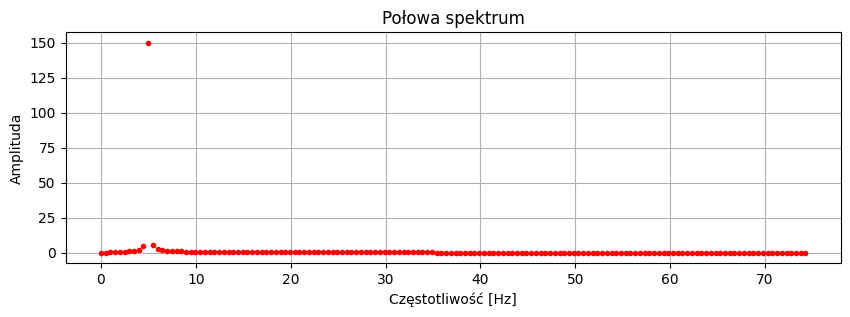

In [10]:
# Połowa spektrum
half_N = N // 2
freq_half = frequency[:half_N]
ampl_half = ampl[:half_N]

plt.figure(figsize=(10, 3))
plt.plot(freq_half, ampl_half, 'or', markersize=3)
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Amplituda')
plt.title('Połowa spektrum')
plt.grid(True)
plt.show()

In [11]:
# Okres i rozdzielczość
T = tmax
delta_f = fs / N  # rzeczywista rozdzielczość siatki DFT (fs/N, patrz wyjaśnienie niżej)
print(f'T = {T:.4f} s')
print(f'1/T = {1/T:.4f} Hz')
print(f'Δf = fs/N = {delta_f:.4f} Hz')
expected_freq = outstanding_ind[0] * fs / N  # dodatnia częstotliwość z pary symetrycznych indeksów
print(f'Częstotliwość dominującej składowej: {expected_freq:.2f} Hz')

T = 2.0000 s
1/T = 0.5000 Hz
Δf = fs/N = 0.4983 Hz
Częstotliwość dominującej składowej: 4.98 Hz


### Korelacja z wartościami współczynników

Dla sygnału $\sin(2\pi\cdot 5\cdot t)$ oczekujemy:

- Dominujący szczyt przy $f=5$ Hz,
- Amplituda $\approx N/2$ dla pojedynczej sinusoidy,
- Rozdzielczość $\Delta f = f_s/N \approx 0{,}4983$ Hz -- **nie dokładnie** $1/T=0{,}5$ Hz.

Ta drobna rozbieżność bierze się stąd, że siatka czasu `t = np.linspace(0, tmax, N)` obejmuje **oba** krańce przedziału (domknięty odcinek $[0, T]$), a próbka w $t=T$ pokrywa się z próbką w $t=0$ z uwagi na okresowość sygnału -- dokładnie ten sam mechanizm "ostatnia próbka = pierwsza, po cichu zdublowana", co w Zad 6 sprawdzianu 2. Czyli spośród $N=301$ próbek przekazanych do DFT tylko $N-1=300$ jest niezależnych, a $\Delta f = f_s/N$ (zamiast $f_s/(N-1)=1/T$ dokładnie) daje wartość nieco różną od $1/T$. Przy dużym $N$ różnica jest pomijalna, ale warto pamiętać, skąd się bierze.

Okres obserwacji $T$ determinuje rozdzielczość: im dłuższy czas, tym węższe piki widmowe.

### Współczynniki DFT jako współczynniki korelacji z harmonicznymi

Kluczowa idea: DFT liczy współczynniki korelacji pomiędzy sygnałem a kolejnymi harmonicznymi sygnału wzorcowego o okresie równym długości okna obserwacji $T$. Częstotliwość podstawowa okna to $f_{okna} = 1/T$; k-ta harmoniczna tej częstotliwości to $k \cdot f_{okna}$.

W naszym przykładzie $T=2{,}0$ s, więc $f_{okna}=0{,}5$ Hz, a sygnał ma częstotliwość $f_{sygnału}=5$ Hz. Ponieważ $5 = 10 \cdot 0{,}5$, dziesiąta harmoniczna okna „wstrzeliwuje się” dokładnie w częstotliwość sygnału — stąd współczynnik korelacji (amplituda DFT) jest tam maksymalny, a pozostałe współczynniki są bliskie zeru. To jest właśnie przypadek pokazany wyżej: okres okna próbkowania jest **wielokrotnością** okresu sygnału, czyli najprostszy możliwy przypadek.

## Ćwiczenie 2 — efekt okna (przeciek widma / spectral leakage)

Powyżej pokazany był szczególny przypadek: okres okna próbkowania $T$ był wielokrotnością okresu sygnału (10 pełnych okresów sygnału 5 Hz mieściło się dokładnie w oknie $T=2{,}0$ s), więc któraś z harmonicznych okna „wstrzeliła się” idealnie w częstotliwość sygnału.

Co się stanie, jeżeli okres okna **nie** jest wielokrotnością okresu sygnału? Sprawdźmy — powtórzmy dokładnie te same obliczenia, zmieniając tylko `tmax` z `2.0` na `2.22` s (tak jak sugeruje ćwiczenie w wersji MATLAB), i porównajmy widma.

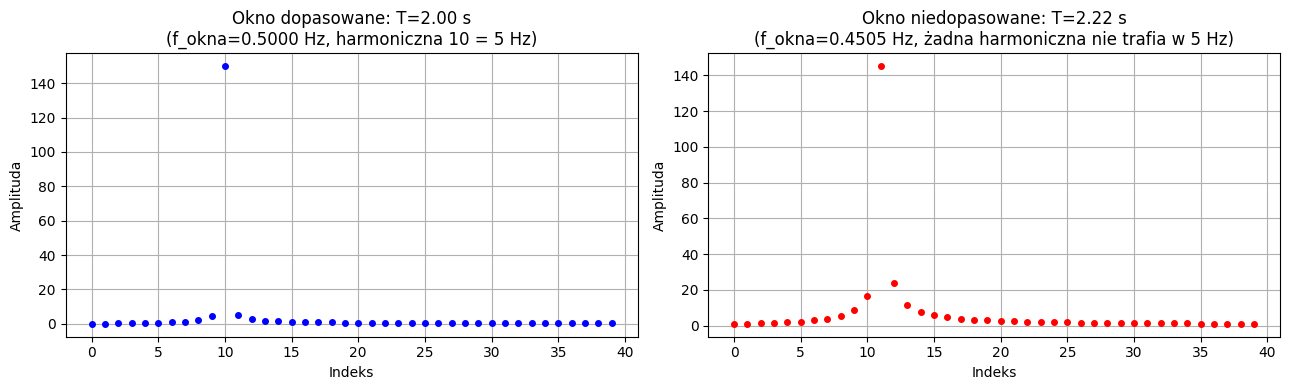

Maksymalna amplituda -- okno dopasowane:    149.97
Maksymalna amplituda -- okno niedopasowane: 145.16
Energia "rozlana" na sąsiednie indeksy zamiast skoncentrowana w jednym prążku.


In [12]:
tmax_leak = 2.22  # NIE jest wielokrotnością okresu sygnału (0.2 s)
t_leak = np.linspace(0, tmax_leak, N)
h_leak = tmax_leak / (N - 1)
fs_leak = 1 / h_leak

y_leak = f_signal(t_leak)
dft_leak = np.fft.fft(y_leak)
ampl_leak = np.abs(dft_leak)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ampl[:40], 'ob', markersize=4)
axes[0].set_title(f'Okno dopasowane: T={tmax:.2f} s\n(f_okna={1/tmax:.4f} Hz, harmoniczna 10 = 5 Hz)')
axes[0].set_xlabel('Indeks'); axes[0].set_ylabel('Amplituda'); axes[0].grid(True)

axes[1].plot(ampl_leak[:40], 'or', markersize=4)
axes[1].set_title(f'Okno niedopasowane: T={tmax_leak:.2f} s\n(f_okna={1/tmax_leak:.4f} Hz, żadna harmoniczna nie trafia w 5 Hz)')
axes[1].set_xlabel('Indeks'); axes[1].set_ylabel('Amplituda'); axes[1].grid(True)
plt.tight_layout()
plt.show()

print(f'Maksymalna amplituda -- okno dopasowane:    {ampl.max():.2f}')
print(f'Maksymalna amplituda -- okno niedopasowane: {ampl_leak.max():.2f}')
print(f'Energia "rozlana" na sąsiednie indeksy zamiast skoncentrowana w jednym prążku.')

Widać wyraźnie: gdy żadna harmoniczna okna nie trafia dokładnie w częstotliwość sygnału, energia sygnału **rozlewa się** na sąsiednie prążki widma zamiast skupić w jednym miejscu — maksymalna amplituda spada (energia sygnału nie zniknęła, tylko rozproszyła się), a wokół głównego prążka pojawiają się dodatkowe, mniejsze prążki. To zjawisko nazywa się **przeciekiem widma (spectral leakage)** i wynika z tego, że DFT zawsze zakłada okresowość sygnału z okresem równym długości okna — jeżeli rzeczywisty sygnał tej okresowości nie spełnia, na granicy okna powstaje efektywna nieciągłość, którą DFT „widzi” jako dodatkowe składowe częstotliwościowe.

## Ćwiczenie

| Sygnał | Zadanie |
|--------|--------|
| $x(t)=\cos(2\pi\cdot 3\,t)+e^{i\,2\pi\cdot 7\,t}$ | Porównaj zespolone widmo z rzeczywistym |
| $x(t)=\sum_{k=1}^5 \frac{1}{k}\sin(2\pi\cdot k\cdot 10\,t)$ | Zidentyfikuj 5 szczytów w widmie |
| Sygnał z fazą | $x(t)=\sin(2\pi\cdot 8\,t + \pi/4)$ — oceń fazę $X[k]$ |

Przeanalizuj widmo zespolone, oblicz amplitudy i fazy, zwizualizuj w płaszczyźnie zespolonej.